In [5]:
%pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 10.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [datasets]/10 [datasets]ess]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor

model_id = "PekingU/rtdetr_v2_r18vd"

# On définit nos labels
id2label = {0: "field"}
label2id = {"field": 0}

# Chargement du processeur
processor = RTDetrImageProcessor.from_pretrained(model_id)

# Chargement du modèle en ignorant les tailles de classes précédentes
model = RTDetrV2ForObjectDetection.from_pretrained(
    model_id,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# --- ASTUCE CPU : ON GÈLE LE BACKBONE ---
# On ne va entraîner que la partie qui détecte tes objets spécifiques
for param in model.model.backbone.parameters():
    param.requires_grad = False

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 529/529 [00:00<00:00, 2834.35it/s]
RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r18vd
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([1])          
model.enc_score_head.weight                | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([1, 256])
model.decoder.cla

In [2]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./rtdetr_sap_checkpoints",
    per_device_train_batch_size=2, 
    num_train_epochs=30,           
    learning_rate=1e-4,            
    save_total_limit=2,
    logging_steps=5,
    eval_strategy="steps",         
    eval_steps=10,
    use_cpu=True,                  
    remove_unused_columns=False,
    push_to_hub=False,
)

In [3]:
from datasets import Dataset, Features, Image, Sequence, Value, load_dataset
import json

def load_custom_dataset(json_path, img_dir):
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
    
    # On prépare les listes pour le dataset
    images = []
    annotations = []
    
    # On crée un dictionnaire pour regrouper les annotations par image
    img_to_anns = {img['id']: [] for img in coco_data['images']}
    for ann in coco_data['annotations']:
        img_to_anns[ann['image_id']].append(ann)
        
    dataset_dict = {
        "image": [],
        "objects": []
    }

    for img_info in coco_data['images']:
        path = os.path.join(img_dir, img_info['file_name'])
        if os.path.exists(path):
            dataset_dict["image"].append(path)
            
            anns = img_to_anns[img_info['id']]
            dataset_dict["objects"].append({
                "bbox": [a['bbox'] for a in anns],
                "category": [a['category_id'] for a in anns],
                "area": [a['area'] for a in anns],
                "id": [a['id'] for a in anns]
            })
            
    return Dataset.from_dict(dataset_dict).cast_column("image", Image())

# Chargement final
train_ds = load_custom_dataset('dataset/annotations_train.json', 'dataset/train-copy')
test_ds = load_custom_dataset('dataset/annotations_test.json', 'dataset/test-copy')

from datasets import DatasetDict
dataset = DatasetDict({"train": train_ds, "test": test_ds})

In [4]:
def preprocess_fn(batch):
    images = [img.convert("RGB") for img in batch["image"]]
    # Format attendu par RT-DETR : [{'image_id': ..., 'annotations': [...]}, ...]
    targets = []
    for i in range(len(images)):
        ann = batch["objects"][i]
        targets.append({
            "image_id": torch.tensor([i]),
            "annotations": [
                {"bbox": b, "category_id": c, "area": a} 
                for b, c, a in zip(ann["bbox"], ann["category"], ann["area"])
            ]
        })
    
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    return inputs

# Appliquer la préparation
dataset["train"] = dataset["train"].with_transform(preprocess_fn)
dataset["test"] = dataset["test"].with_transform(preprocess_fn)

In [5]:
def collate_fn(batch):
    # On récupère les pixels_values et les labels de chaque élément du batch
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]
    
    # On empile les images dans un seul tenseur
    encoding = processor.pad(pixel_values, return_tensors="pt")
    
    batch_dict = {}
    batch_dict["pixel_values"] = encoding["pixel_values"]
    batch_dict["labels"] = labels
    return batch_dict

In [6]:
print(f"Nombre d'images dans train : {len(train_ds)}")
print(f"Exemple d'objet : {train_ds[0] if len(train_ds) > 0 else 'VIDE'}")

Nombre d'images dans train : 18
Exemple d'objet : {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1388x882 at 0x778DCE237F40>, 'objects': {'area': [11062.682571134734, 6064.89884191286, 8897.743997186084, 9366.046312827455, 28205.61815846565], 'bbox': [[279.07099704284906, 293.4954796383711, 272.79133020954254, 40.55364429154336], [279.07099704284906, 334.04912392991446, 164.50774875231951, 36.86694935594848], [751.7704776349572, 335.89247139771186, 254.04994111117696, 35.02360188815106], [279.07099704284906, 459.3967517401392, 254.04994111117696, 36.86694935594848], [279.07099704284906, 542.3473877910234, 695.5137732060091, 40.55364429154336]], 'category': [0, 0, 0, 0, 0], 'id': [0, 1, 2, 3, 4]}}


In [7]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=processor, 
    data_collator=collate_fn,
)

print("🚀 Lancement de l'entraînement sur CPU...")
trainer.train()

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/transformers/models/rt_detr/image_processing_rt_detr.py:242: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  image_id = np.asarray([image_id], dtype=np.int64)


Step,Training Loss,Validation Loss
10,76.861127,79.094292
20,39.749854,42.722557
30,27.955847,29.905956
40,26.602966,23.921553
50,20.478659,20.909433
60,19.737944,18.374245
70,18.772043,16.206173
80,17.081017,17.575214
90,16.774167,17.155006
100,16.089882,16.603458


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


TrainOutput(global_step=270, training_loss=24.821044003521955, metrics={'train_runtime': 1141.1062, 'train_samples_per_second': 0.473, 'train_steps_per_second': 0.237, 'total_flos': 7.991552212992e+16, 'train_loss': 24.821044003521955, 'epoch': 30.0})

In [8]:
# Sauvegarde locale dans un dossier spécifique
output_dir = "./trained_rtdetr_sap_model"

# Sauvegarde des poids du modèle fine-tuné
trainer.save_model(output_dir)

# Sauvegarde du processeur (indispensable pour le futur redimensionnement des images)
processor.save_pretrained(output_dir)

print(f"✅ Modèle sauvegardé avec succès dans : {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 529/529 [00:01<00:00, 477.61it/s]


✅ Modèle chargé (76.78 MB)


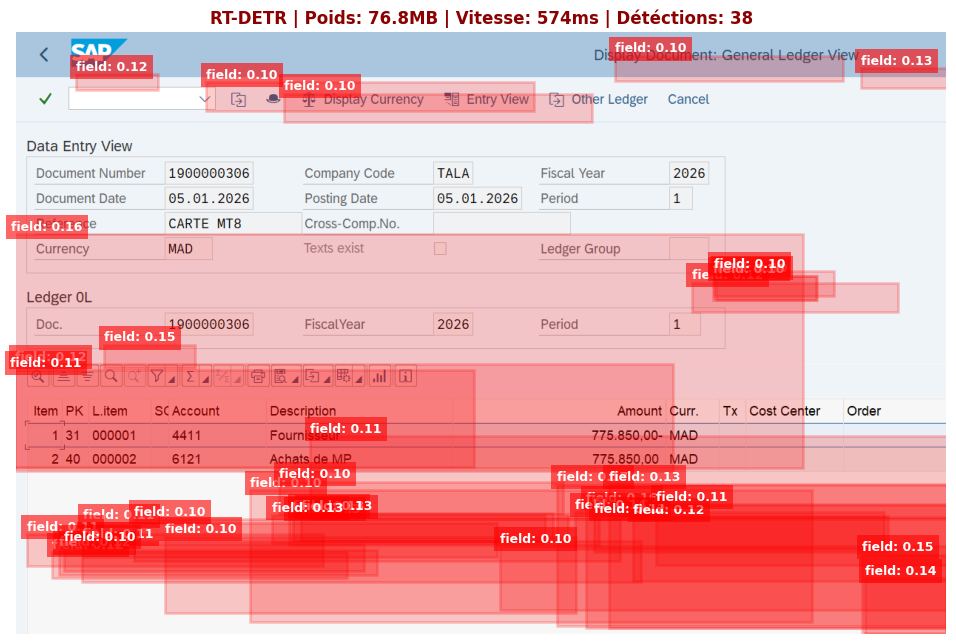

📊 ANALYSE FINALE :
   - Temps d'inférence moyen : 573.59 ms
   - Nombre d'objets trouvés : 38


In [1]:
import torch
from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
import os

# 1. Configuration des chemins
model_path = "./trained_rtdetr_sap_model"

# 2. Fonction pour mesurer le poids du dossier modèle
def get_model_size(model_dir):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(model_dir):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024) # Retourne en MB

# 3. Chargement (à ne faire qu'une fois)
if os.path.exists(model_path):
    processor = RTDetrImageProcessor.from_pretrained(model_path)
    model = RTDetrV2ForObjectDetection.from_pretrained(model_path)
    model.eval()
    poids_reel = get_model_size(model_path)
    print(f"✅ Modèle chargé ({poids_reel:.2f} MB)")
else:
    print("❌ Dossier modèle introuvable !")

def test_on_sap_image_with_metrics(image_path, threshold=0.10):
    image = PILImage.open(image_path).convert("RGB")
    
    # --- MESURE DE LA VITESSE ---
    # Préparation des inputs
    inputs = processor(images=image, return_tensors="pt")
    
    # Warm-up (pour stabiliser le CPU)
    with torch.no_grad():
        _ = model(**inputs)
    
    # Mesure réelle sur 3 itérations
    start_time = time.time()
    for _ in range(3):
        with torch.no_grad():
            outputs = model(**inputs)
    end_time = time.time()
    
    vitesse_ms = ((end_time - start_time) / 3) * 1000
    
    # --- POST-PROCESSING ---
    results = processor.post_process_object_detection(
        outputs, 
        target_sizes=torch.tensor([image.size[::-1]]), 
        threshold=threshold
    )[0]
    
    # --- AFFICHAGE ---
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)
    
    detections_count = 0
    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        xmin, ymin, xmax, ymax = box.tolist()
        detections_count += 1
        
        # Rectangle avec transparence pour le style Ederest
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='red', alpha=0.2
        )
        ax.add_patch(rect)
        
        label_text = f"{model.config.id2label[label.item()]}: {score:.2f}"
        ax.text(xmin, ymin - 5, label_text, color='white', weight='bold', fontsize=9,
                bbox=dict(facecolor='red', alpha=0.6, edgecolor='none'))
    
    # Titre avec les métriques pour ton rapport
    info_titre = f"RT-DETR | Poids: {poids_reel:.1f}MB | Vitesse: {vitesse_ms:.0f}ms | Détéctions: {detections_count}"
    plt.title(info_titre, color='darkred', weight='bold')
    plt.axis('off')
    plt.show()
    
    print(f"📊 ANALYSE FINALE :")
    print(f"   - Temps d'inférence moyen : {vitesse_ms:.2f} ms")
    print(f"   - Nombre d'objets trouvés : {detections_count}")

# Lancement du test
test_img_path = "dataset/test-copy/img_1768298450246.png" 
if os.path.exists(test_img_path):
    test_on_sap_image_with_metrics(test_img_path)